Github Solutions to Problem 1d and 1e. 

**(d)** Set $\alpha = \beta = 1$ and $L = 20$. Simulate the Markov chain $N = 1000$ times starting with the vesicle at the $i = 0$ site until it reaches the $i = L$ site. Estimate the average transport time $m_0$ from your simulations. Compare with the theoretical value in (b). From your simulations, calculate the variance of the observed transport time. If $N = 1000$ simulations are not enough to get good agreement, increase $N$.

**(e)** *[+5 Bonus – Warning: I haven’t done this, I don’t know how hard it will be!]* Use a one-step argument to find the second moment $\mathbb{E}[T^2 \mid X(0) = 0]$, and use this to derive a formula for the variance in the transport time. Compare with the value found in (d).

In [4]:
import numpy as np

# Parameters
L = 20
alpha = 1.0
beta = 1.0
seed = 5350


# Problem 1d

def simulate_delivery_times(N, L, alpha, beta, seed=5350):
    rng = np.random.default_rng(seed)

    delivery_times = np.zeros(N)

    for trial in range(N):
        position = 0
        time = 0.0

        while position < L:
            if position == 0:
                rate = alpha
                time += rng.exponential(1 / rate)
                position += 1
            else:
                rate = alpha + beta
                time += rng.exponential(1 / rate)

                if rng.random() < alpha / rate:
                    position += 1
                else:
                    position -= 1

        delivery_times[trial] = time

    return delivery_times


theory_mean = L * (L + 1) / (2 * alpha)
theory_var = L * (L + 1) * (L**2 + L + 1) / (6 * alpha**2)

print("Problem 1(d): Simulation Results")
print("--------------------------------")

for N in [1_000, 10_000, 100_000]:
    times = simulate_delivery_times(N, L, alpha, beta, seed)

    sim_mean = np.mean(times)
    sim_var = np.var(times, ddof=1)

    print(f"N = {N}")
    print(f"Simulated mean:      {sim_mean:.4f}")
    print(f"Theoretical mean:    {theory_mean:.4f}")
    print(f"Simulated variance:  {sim_var:.4f}")
    print(f"Theoretical variance:{theory_var:.4f}")
    print()


# Problem 1e

def build_generator_matrix(L, alpha, beta):
    """
    Builds the generator matrix Q for the transient states 0, 1, ..., L-1.
    State L is absorbing, so it is not included.
    """
    Q = np.zeros((L, L))

    # reflecting boundary at 0
    Q[0, 0] = -alpha
    Q[0, 1] = alpha

    # interior states
    for i in range(1, L):
        Q[i, i] = -(alpha + beta)
        Q[i, i - 1] = beta

        if i + 1 < L:
            Q[i, i + 1] = alpha

    return Q


Q = build_generator_matrix(L, alpha, beta)

# First moment: Qm = -1
m = np.linalg.solve(Q, -np.ones(L))

# Second moment: Qs = -2m
s = np.linalg.solve(Q, -2 * m)

second_moment = s[0]
variance = second_moment - m[0]**2

print("Problem 1(e): Theoretical Second Moment")
print("---------------------------------------")
print(f"E[T | X(0)=0]:       {m[0]:.4f}")
print(f"E[T^2 | X(0)=0]:     {second_moment:.4f}")
print(f"Var(T | X(0)=0):     {variance:.4f}")
print(f"Closed-form Var(T):  {theory_var:.4f}")

Problem 1(d): Simulation Results
--------------------------------
N = 1000
Simulated mean:      214.0223
Theoretical mean:    210.0000
Simulated variance:  26556.5847
Theoretical variance:29470.0000

N = 10000
Simulated mean:      207.7044
Theoretical mean:    210.0000
Simulated variance:  29491.6126
Theoretical variance:29470.0000

N = 100000
Simulated mean:      209.6790
Theoretical mean:    210.0000
Simulated variance:  29083.9063
Theoretical variance:29470.0000

Problem 1(e): Theoretical Second Moment
---------------------------------------
E[T | X(0)=0]:       210.0000
E[T^2 | X(0)=0]:     73570.0000
Var(T | X(0)=0):     29470.0000
Closed-form Var(T):  29470.0000


**(e)** *[+5 Bonus – Warning: I haven’t done this, I don’t know how hard it will be!]* Use a one-step argument to find the second moment $\mathbb{E}[T^2 \mid X(0) = 0]$, and use this to derive a formula for the variance in the transport time. Compare with the value found in (d).

4. Plotting the two expressions found. 

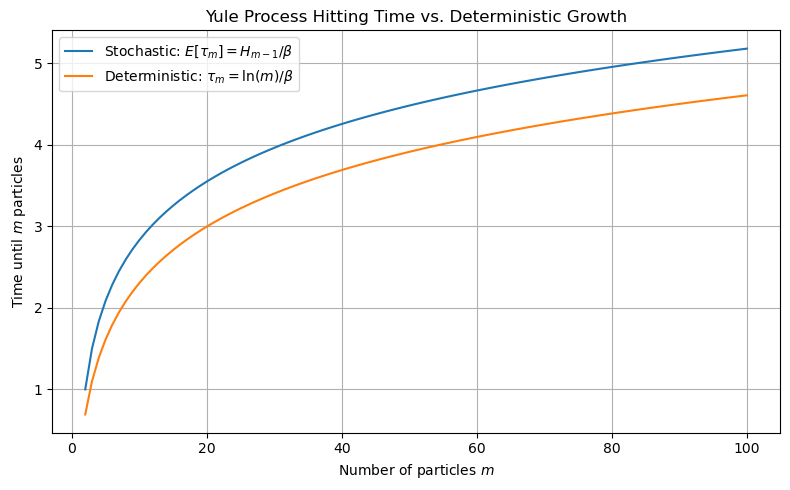

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
beta = 1.0
m_values = np.arange(2, 101)

# Stochastic Yule result:
# E[tau_m] = (1 / beta) * H_{m-1}
harmonic_values = np.array([
    np.sum(1 / np.arange(1, m))
    for m in m_values
])

expected_tau = harmonic_values / beta

# Deterministic exponential growth result:
# tau_m = ln(m) / beta
deterministic_tau = np.log(m_values) / beta

# Plot
plt.figure(figsize=(8, 5))
plt.plot(m_values, expected_tau, label=r"Stochastic: $E[\tau_m] = H_{m-1}/\beta$")
plt.plot(m_values, deterministic_tau, label=r"Deterministic: $\tau_m = \ln(m)/\beta$")

plt.xlabel(r"Number of particles $m$")
plt.ylabel(r"Time until $m$ particles")
plt.title(r"Yule Process Hitting Time vs. Deterministic Growth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()